In [3]:
!pip install numpy matplotlib scipy pandas


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math

In [5]:
u = 8.01
k_0 = math.log(2) / 2
k_1 = 0.319
k_2 = 0.184
k_3 = 0.201

k_D1 = math.log(0.5) / (-10)
k_D2 = math.log(0.5) / (-4)
k_D3 = math.log(0.5) / (-4)
P_0 = 3

In [6]:
days = 14
total_time = 24 * days
total_steps = 300

tau_1 = np.arange(2, total_time, 24)
tau_2 = np.arange(0, total_time, 12)
tau_3 = np.arange(24, total_time, 48)

In [7]:
def model(t, y):
    P, D_1, D_2, D_3 = y

    dD_1dt = -k_D1 * D_1
    dD_2dt = -k_D2 * D_2
    dD_3dt = -k_D3 * D_3
    dPdt = -(k_0 + k_1 * D_1 + k_2 * D_2 + k_3 * D_3) * P + k_0 * u
    return [dPdt, dD_1dt, dD_2dt, dD_3dt]

In [8]:
dt = 0.1
time = np.arange(0, total_time, dt)
T,P,D1,D2,D3 = [],[],[],[],[]
y_0 = [P_0, 0, 0, 0]

for t in time:
    T.append(t)
    P.append(y_0[0])
    D1.append(y_0[1])
    D2.append(y_0[2])
    D3.append(y_0[3])

    sol = solve_ivp(model, t_span=[t, t + dt], y0=y_0, t_eval=[t + dt])
    
    y_0 = sol.y[:,0]

    if np.any(np.isclose(t, tau_1, atol=dt/2)):
        y_0[1] += 1
    if np.any(np.isclose(t, tau_2, atol=dt/2)):
        y_0[2] += 1
    if np.any(np.isclose(t, tau_3, atol=dt/2)):
        y_0[3] += 1


In [9]:
df = pd.DataFrame({"T": T,"P": P, "D1": D1, "D2": D2, "D3": D3})
pd.set_option('display.max_rows', 1000)
print(df.head(1000))

        T         P        D1        D2        D3
0     0.0  3.000000  0.000000  0.000000  0.000000
1     0.1  3.170659  0.000000  1.000000  0.000000
2     0.2  3.277692  0.000000  0.982821  0.000000
3     0.3  3.380226  0.000000  0.965936  0.000000
4     0.4  3.478536  0.000000  0.949342  0.000000
5     0.5  3.572880  0.000000  0.933033  0.000000
6     0.6  3.663494  0.000000  0.917004  0.000000
7     0.7  3.750601  0.000000  0.901250  0.000000
8     0.8  3.834407  0.000000  0.885768  0.000000
9     0.9  3.915105  0.000000  0.870551  0.000000
10    1.0  3.992876  0.000000  0.855595  0.000000
11    1.1  4.067886  0.000000  0.840896  0.000000
12    1.2  4.140292  0.000000  0.826450  0.000000
13    1.3  4.210240  0.000000  0.812252  0.000000
14    1.4  4.277867  0.000000  0.798298  0.000000
15    1.5  4.343301  0.000000  0.784584  0.000000
16    1.6  4.406659  0.000000  0.771105  0.000000
17    1.7  4.468055  0.000000  0.757858  0.000000
18    1.8  4.527591  0.000000  0.744839  0.000000


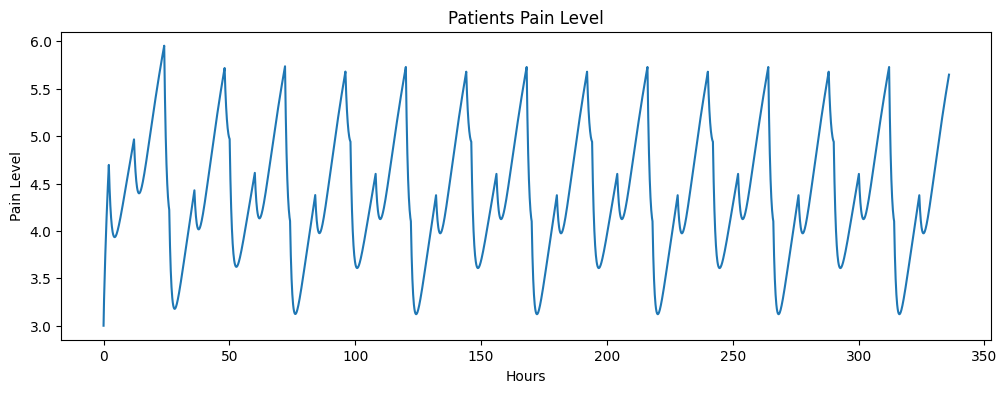

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title("Patients Pain Level")
plt.xlabel("Hours")
plt.ylabel("Pain Level")

plt.plot(time, P)
plt.show()

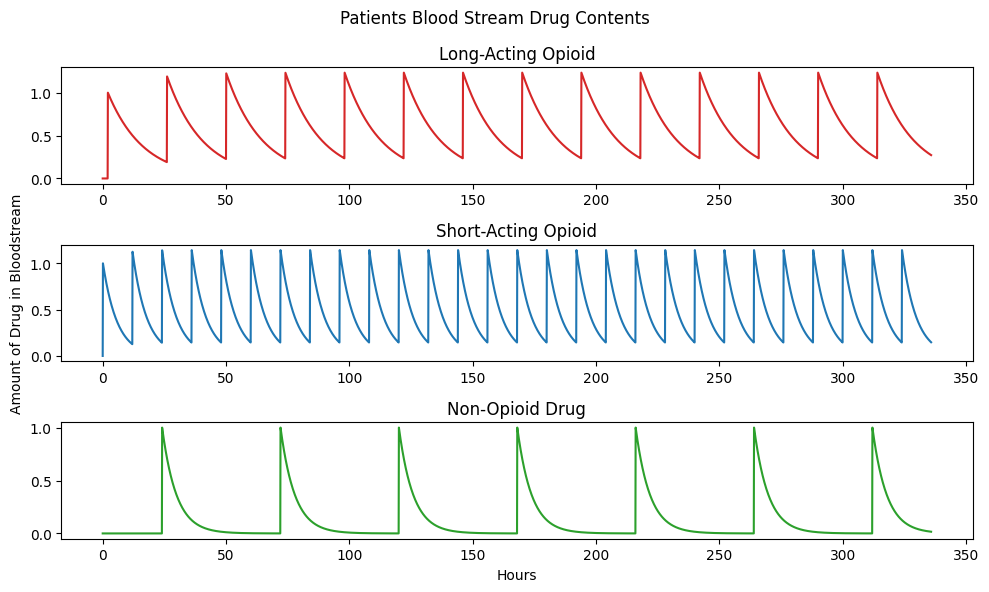

In [11]:
fig, axs = plt.subplots(3)
fig.suptitle("Patients Blood Stream Drug Contents")

fig.set_figwidth(10)
fig.set_figheight(6)
axs[0].plot(time, D1, 'tab:red')
axs[0].set_title("Long-Acting Opioid")
axs[1].plot(time, D2, 'tab:blue')
axs[1].set_title("Short-Acting Opioid")
axs[2].plot(time, D3, 'tab:green')
axs[2].set_title("Non-Opioid Drug")
plt.xlabel("Hours")
axs[1].set_ylabel("Amount of Drug in Bloodstream")
fig.tight_layout()

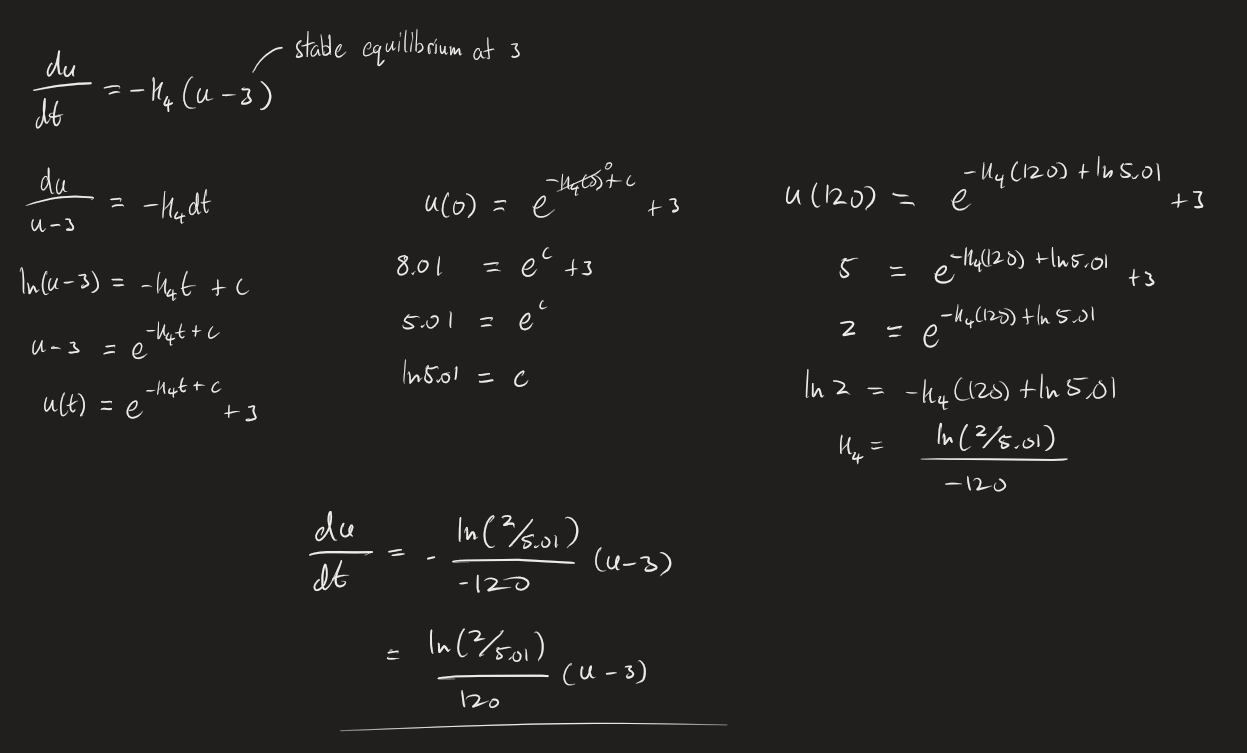

In [102]:
k_4 = math.log(2 / 5.01) / -120
def model_alt(t, y):
    P, U, D_1, D_2, D_3 = y

    dD_1dt = -k_D1 * D_1
    dD_2dt = -k_D2 * D_2
    dD_3dt = -k_D3 * D_3
    du_dt = -k_4 * (U - 3)
    dP_dt = -(k_0 + k_1 * D_1 + k_2 * D_2 + k_3 * D_3) * P + k_0 * U
    return [dP_dt, du_dt, dD_1dt, dD_2dt, dD_3dt]

In [103]:
time = np.arange(0, total_time, dt)
T,P, U, D1,D2,D3 = [],[],[],[],[],[]
u_0 = u
y_0 = [P_0, u_0, 0, 0, 0]

for index, t in enumerate(time):
    T.append(t)
    P.append(y_0[0])
    U.append(y_0[1])
    D1.append(y_0[2])
    D2.append(y_0[3])
    D3.append(y_0[4])

    sol = solve_ivp(model_alt, t_span=[t, t + dt], y0=y_0, t_eval=[t + dt])
    
    y_0 = sol.y[:,0]

    if np.any(np.isclose(t, tau_1, atol=dt/2)):
        y_0[2] += 1
    if np.any(np.isclose(t, tau_2, atol=dt/2)):
        y_0[3] += 1
    if np.any(np.isclose(t, tau_3, atol=dt/2)):
        y_0[4] += 1

In [104]:
df = pd.DataFrame({"T": T,"P": P, "U": U, "D1": D1, "D2": D2, "D3": D3})
pd.set_option('display.max_rows', 2000)
print(df.head(2000))

          T         P         U        D1        D2        D3
0       0.0  3.000000  8.010000  0.000000  0.000000  0.000000
1       0.1  3.170593  8.006168  0.000000  1.000000  0.000000
2       0.2  3.277435  8.002338  0.000000  0.982821  0.000000
3       0.3  3.379658  7.998512  0.000000  0.965936  0.000000
4       0.4  3.477545  7.994688  0.000000  0.949342  0.000000
5       0.5  3.571356  7.990867  0.000000  0.933033  0.000000
6       0.6  3.661336  7.987050  0.000000  0.917004  0.000000
7       0.7  3.747710  7.983235  0.000000  0.901250  0.000000
8       0.8  3.830691  7.979423  0.000000  0.885768  0.000000
9       0.9  3.910476  7.975614  0.000000  0.870551  0.000000
10      1.0  3.987247  7.971808  0.000000  0.855595  0.000000
11      1.1  4.061177  7.968005  0.000000  0.840896  0.000000
12      1.2  4.132426  7.964204  0.000000  0.826450  0.000000
13      1.3  4.201143  7.960407  0.000000  0.812252  0.000000
14      1.4  4.267468  7.956613  0.000000  0.798298  0.000000
15      

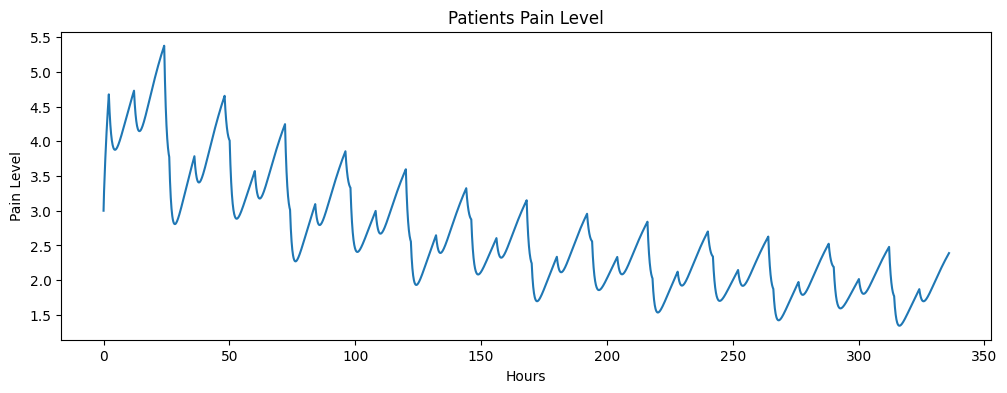

In [105]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title("Patients Pain Level")
plt.xlabel("Hours")
plt.ylabel("Pain Level")

plt.plot(time, P)
plt.show()

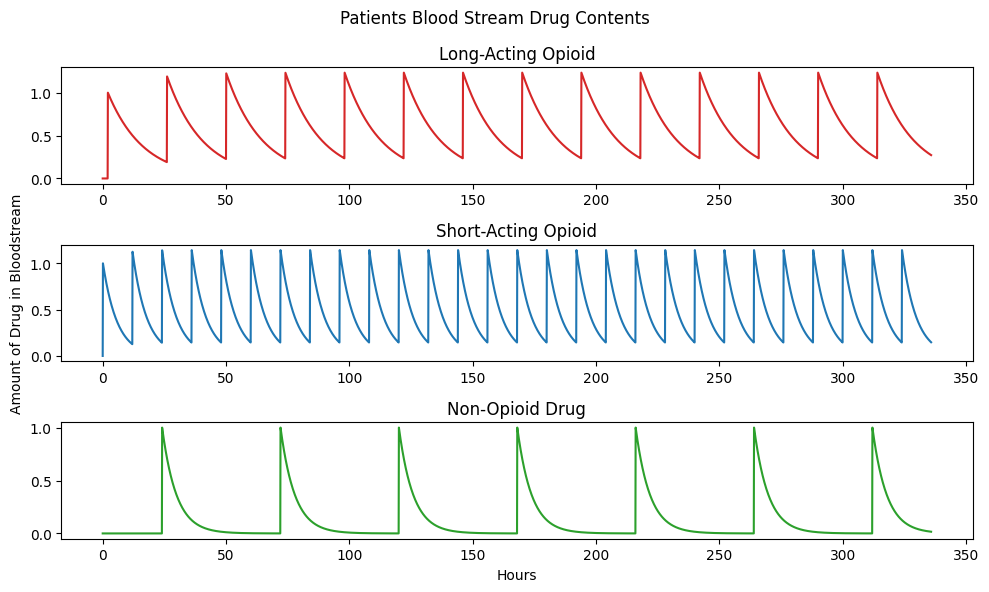

In [ ]:
# should be the same as the original model
fig, axs = plt.subplots(3)
fig.suptitle("Patients Blood Stream Drug Contents")

fig.set_figwidth(10)
fig.set_figheight(6)
axs[0].plot(time, D1, 'tab:red')
axs[0].set_title("Long-Acting Opioid")
axs[1].plot(time, D2, 'tab:blue')
axs[1].set_title("Short-Acting Opioid")
axs[2].plot(time, D3, 'tab:green')
axs[2].set_title("Non-Opioid Drug")
plt.xlabel("Hours")
axs[1].set_ylabel("Amount of Drug in Bloodstream")
fig.tight_layout()